In [1]:
# Ignore warning
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import glob, os
import matplotlib.pyplot as plt
import numpy as np
import geopandas
import netCDF4
import h5py
import datetime as dt
import pyproj

from scipy.interpolate import griddata

import rasterio
from rasterio.plot import show

from shapely.geometry import Point, LineString, shape
from shapely.geometry import box

# check pytorch version
import torch    
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim    

from tqdm import tqdm

from pyproj import Proj, transform
from shapely.geometry import Polygon
import cartopy.crs as ccrs
import torch
from torch.utils.data import DataLoader

import time

from scipy.interpolate import griddata

# from mpl_toolkits.basemap import Basemap

# import cdsapi
# import xarray as xr
from urllib.request import urlopen

from urllib.request import urlretrieve

import pickle

import scipy.io as sio

%load_ext autoreload
%autoreload 2

import dgl
from dgl.data import DGLDataset
from dgl.dataloading import GraphDataLoader
from dgl import save_graphs, load_graphs
import torch
import os


from functions import *
from DGL_model import *

# Read ISSM file & Retrieve elapsed time

In [41]:
et0 = {}

for grid in [10000]:
    files = glob.glob(f'D:\\ISSM\\version3\\PIG_transient_m{str(grid).zfill(5)}_r*.mat')[:]

    et0[grid] = np.zeros(len(files))

    train_list = []
    val_list = []
    i = 0

    for filename in tqdm(files[:]):

        rate = float(filename[-7:-4])
        test = sio.loadmat(filename)

        xc = test['S'][0][0][0]
        yc = test['S'][0][0][1]
        elements = test['S'][0][0][2]-1

        # smb = test['S'][0][0][3]
        # vx = test['S'][0][0][4]
        # vy = test['S'][0][0][5]
        vel = test['S'][0][0][6]
        # H = test['S'][0][0][7]
        # f = test['S'][0][0][8]

        et0[grid][i] = test['S'][0][0][11][0][0]
        i += 1
        
    print(grid, elements.shape, xc.shape)

    print(grid, np.sum(et0[grid]))

100%|█████████████████████████████████████████████████████████████████████████████████| 36/36 [00:12<00:00,  2.97it/s]

10000 (3511, 3) (1833, 1)
10000 541.9777600000001


# Measure elapsed time
## Elapsed time for GNN emulators

In [345]:
in_channels = 10
out_channels = 3

if 'et1' in locals():
    pass
else:
    et1 = {}

for grid in [2000, 5000, 10000]:
    
    et1[grid] = {}
    
    # train_dataset = CNN_PIG_Dataset(train_files[:])
    test_gnn_files = glob.glob(f"D:\\ISSM\\version3\\PIG_transient_m{str(grid).zfill(5)}_r*.mat") # [f for f in test_files if f.split("_m")[1][:5] == str(grid).zfill(5) ]
    
    test_graph = GNN_PIG_Dataset(test_gnn_files[:1])
    test_set = test_graph[0]
    
    test = sio.loadmat(test_gnn_files[0])

    xc = test['S'][0][0][0]
    yc = test['S'][0][0][1]
    # point to calculate distance   

    timestep = test['S'][0][0][3].shape[0]
    idxs = np.arange(0, timestep)
    n_nodes = len(test_set.nodes())

    print("M0: ", grid, "; Nodes: ", n_nodes, "; Elements: ", len(elements))   

    for model_type in ["mlp", "gcn"]:
        
        hidden_channels = 128
        if model_type == "gcn":
            model = GCN(in_channels, out_channels, hidden_channels)  # Graph convolutional network    
        elif model_type == "mlp":
            model = MLP(in_channels, out_channels, hidden_channels)  # Fully connected network
        elif model_type == "gat":
            model = GAT(in_channels, out_channels, hidden_channels)  # Graph convolutional network 
        elif model_type == "egcn":
            model = EGCN(in_channels, out_channels-2, hidden_channels, 5) # Equivariant Graph convolutional network 

        for device_name in ["cpu", "cuda"]:

            # emulator = f"D:\\ISSM\\model\\torch_dgl_PIG_{model_type}_6384_lr0.001_ch{out_channels}.pth"
            emulator = f"D:\\ISSM\\model\\torch_dgl_PIG_{model_type}_6384_lr0.01_ch{out_channels}.pth"
            device = torch.device(device_name)

            if device_name == "cuda":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.to(device)
            else:
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.module.to(device)

            model.eval()
            et1[grid][model_type + "_" + device_name] = np.zeros(len(test_gnn_files))
            
            for i, _ in tqdm(enumerate(test_gnn_files)):
            
                r = test_gnn_files[i].split("_r")[1][:3]

                test_loader = GraphDataLoader(test_graph, batch_size=12, shuffle=False)  #DataLoader(test_grid, batch_size=1, shuffle=False)               

                for bg in test_loader:   

                    t0 = time.time()

                    bg = bg.to(device)
                    feats = bg.ndata['feat'][:, 2:]
                    coord_feat = bg.ndata['feat'][:, :2] 

                    pred = model(bg, feats)

                    et1[grid][model_type + "_" + device_name][i] += time.time() - t0

            print(model_type + "_" + device_name, np.sum(et1[grid][model_type + "_" + device_name]))
    
print("COMPLETE!")


100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.17s/it]


M0:  2000 ; Nodes:  6384 ; Elements:  12459


36it [01:04,  1.79s/it]


mlp_cpu 56.63756251335144


36it [00:11,  3.22it/s]


...

mlp_cuda 2.1049323081970215


36it [00:49,  1.36s/it]


gcn_cpu 45.039828062057495


36it [00:18,  1.93it/s]

gcn_cuda 14.959420919418335
COMPLETE!


## Elapsed time for CNN emulators

In [346]:
for grid in [2000, 5000, 10000]:
    
    # train_dataset = CNN_PIG_Dataset(train_files[:])
    test_gnn_files = glob.glob(f"D:\\ISSM\\version3\\PIG_transient_m{str(grid).zfill(5)}_r*.mat")
    test_cnn_files = glob.glob(f"D:\\ISSM\\version3\\PIG_transient_m{str(grid).zfill(5)}_r*.pkl")

    print("M0: ", grid, "; Nodes: ", n_nodes, "; Elements: ", len(elements))
    
    test_graph = GNN_PIG_Dataset(test_gnn_files[:1])
    test_grid = CNN_PIG_Dataset(test_cnn_files[:1])

    test_set = test_graph[0]
    
    test = sio.loadmat(test_gnn_files[0])

    xc = test['S'][0][0][0]
    yc = test['S'][0][0][1]
    # point to calculate distance   

    timestep = test['S'][0][0][3].shape[0]
    idxs = np.arange(0, timestep)
    n_nodes = len(test_set.nodes())

    for model_type in ["fcn"]:

        if model_type == "cnn":
            model = CNN(in_channels, out_channels, n_nodes, nrow, ncol, 32)  # convolutional network
        elif model_type == "fcn":
            model = FCN(in_channels, out_channels, 64)

        for device_name in ["cpu", "cuda"]:

            print(f"Model: {model_type}, Device: {device_name}")

            emulator = f"D:\\ISSM\\model\\torch_dgl_PIG_{model_type}_6384_lr0.001_ch{out_channels}.pth"
            device = torch.device(device_name)

            if device_name == "cuda":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.to(device)
            elif device_name == "cpu":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.module.to(device)

            model.eval()
            et1[grid][model_type + "_" + device_name] = np.zeros(len(test_gnn_files))
            sampling = get_sampling_index(test_graph[0].ndata['feat'][:, 0:2], test_grid[0][0][:2])
            
            for i, _ in tqdm(enumerate(test_cnn_files)):

                r = test_cnn_files[i].split("_r")[1][:3]
                
                test_loader = DataLoader(test_grid, batch_size=12, shuffle=False)               

                for (data, target) in test_loader: 

                    t0 = time.time()
                    data.to(device)
                    
                    data = data[:, 2:]
                    coords = data[:, :2]                

                    pred = model(data)
                    pred = pred[:, :out_channels, sampling[:, 0], sampling[:, 1]]
                    
                    et1[grid][model_type + "_" + device_name][i] += time.time() - t0

            print(model_type + "_" + device_name, np.sum(et1[grid][model_type + "_" + device_name]))
    
print("COMPLETE!")

M0:  2000 ; Nodes:  1833 ; Elements:  12459


100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.57it/s]


Model: fcn, Device: cpu


36it [10:31, 17.53s/it]


fcn_cpu 621.7234869003296
Model: fcn, Device: cuda


...

Model: fcn, Device: cpu


36it [10:22, 17.28s/it]


fcn_cpu 612.0311870574951
Model: fcn, Device: cuda


36it [00:31,  1.14it/s]

fcn_cuda 22.456438302993774
COMPLETE!


# Draw PIG maps

In [2]:
from shapely.geometry import Point, LineString, shape
from shapely.geometry import box

text = "D:\\ISSM\\DomainOutline.exp"

with open(text, 'r') as f:
    t = f.readlines()

gdf = geopandas.GeoDataFrame()

for i, x in enumerate(t[5:-1]):
    
    gdf.loc[i, "X"] = float(x.split()[0])
    gdf.loc[i, "Y"] = float(x.split()[1])
    # print(x)
    
gdf.geometry = [Point(xy) for xy in zip(gdf.X, gdf.Y)]

## Create outside cilp polygon
gdf['shape_id'] = 0
polygon = gdf.groupby('shape_id')['geometry'].apply(lambda x: Polygon(x.tolist())).reset_index()

In [3]:
def prepare_grid_data(xc, yc):
    xext = [xc.min(), xc.max()]
    yext = [yc.min(), yc.max()]

    xext = [-1700*1000, -1480*1000]
    yext = [-360*1000, -140*1000]
    
    res = 500

    gridx, gridy = np.meshgrid(np.arange(xext[0], xext[1]+res, res), np.arange(yext[0], yext[1]+res, res))
    coord = np.array([xc[:, 0], yc[:, 0]]).transpose()
    
    ## Read PIG polygon ---------------------------------------------------------------------
    text = "D:\\ISSM\\DomainOutline.exp"

    with open(text, 'r') as f:
        t = f.readlines()

    gdf = geopandas.GeoDataFrame()

    for i, x in enumerate(t[5:-1]):
        gdf.loc[i, "X"] = float(x.split()[0])
        gdf.loc[i, "Y"] = float(x.split()[1])

    gdf.geometry = [Point(xy) for xy in zip(gdf.X, gdf.Y)]
    gdf['shape_id'] = 0
    polygon = gdf.groupby('shape_id')['geometry'].apply(lambda x: Polygon(x.tolist())).reset_index()
    ## -------------------------------------------------------------------------------------

    grid = []
    grid_i = []
    grid_j = []

    for i in range(0, gridx.shape[0]):
        for j in range(0, gridx.shape[1]):
            grid.append(Point(gridx[i, j], gridy[i, j]))
            grid_i.append(i)
            grid_j.append(j)

    gridf = geopandas.GeoDataFrame(pd.DataFrame({'ind_i': grid_i, 'ind_j': grid_j}), geometry=grid)

    pointInPoly = geopandas.sjoin(gridf, polygon, op='within') 

    grid_valid = gridx.copy() * np.nan
    grid_valid[pointInPoly['ind_i'].values, pointInPoly['ind_j'].values] = 1
    print("Polygon prepared!")
    
    return gridx, gridy, grid_valid, coord

def draw_grid_map(y_true, y_pred, c, idxs, gridx, gridy, coord, grid_valid, years_real, model_type, label):
    vmax = [10000, 10000, 2000, 6000]
    vmin = [-10000, -10000, 0, 0]
    cmap = ["RdBu_r", "RdBu_r", "viridis", "jet", "jet"]
    
    xext = [-1700*1000, -1480*1000]
    yext = [-360*1000, -140*1000]

    fig, ax = plt.subplots(3, len(idxs), figsize = (len(idxs)*2,3*2), dpi=100, sharey=True, sharex=True,
                           subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=0, true_scale_latitude = -70)})
    plt.subplots_adjust(hspace=0.05, wspace=0.05)
    
    src = rasterio.open('D:\\ISSM\\Helheim\\snapshot-2023-11-15T00_00_00Z.tif')

    for k, idx in enumerate(idxs):

        ice_true = y_true[k, :, 3]
        th_true = y_true[k, :, 2]
        ice_pred = y_pred[k, :, 3]
        th_pred = y_pred[k, :, 2]

        mask_true = np.zeros(ice_true.shape) # Ice mask (Negative: ice; Positive: no-ice)
        mask_pred = np.zeros(ice_pred.shape) # Ice mask (Negative: ice; Positive: no-ice)

        mask_true[(th_true > 0)] = 1
        mask_pred[(th_pred > 0)] = 1        

        val_true = y_true[k, :, c] * mask_true
        val_pred = y_pred[k, :, c] * mask_pred
        val_diff = val_pred - val_true

        val_true_grid = griddata(coord, val_true, (gridx, gridy), method='linear') * grid_valid
        val_pred_grid = griddata(coord, val_pred, (gridx, gridy), method='linear') * grid_valid
        # val_diff_grid = griddata(coord, val_diff, (gridx, gridy), method='linear') * grid_valid

        if c == 3:
            text_color = "white"; diff_scale = 30
        else:
            text_color = "black"; diff_scale = 15

        true_map = ax[0, k].pcolormesh(gridx, gridy, val_true_grid, vmin = vmin[c], vmax = vmax[c], cmap = cmap[c])
        pred_map = ax[1, k].pcolormesh(gridx, gridy, val_pred_grid, vmin = vmin[c], vmax = vmax[c], cmap = cmap[c])
        diff_map = ax[2, k].pcolormesh(gridx, gridy, val_pred_grid - val_true_grid, vmin = -vmax[c]/diff_scale, vmax = vmax[c]/diff_scale, cmap = "RdBu_r")
        # fig.colorbar(true_map, ax = ax[0, k], shrink = 0.5, orientation = "horizontal", pad = 0.03)
        # fig.colorbar(pred_map, ax = ax[1, k], shrink = 0.5, orientation = "horizontal", pad = 0.03)
        # fig.colorbar(diff_map, ax = ax[2, k], shrink = 0.5, orientation = "horizontal", pad = 0.03)
                   
            
        ax[0, k].annotate(f"ISSM", xy=(0.97, 0.97), xycoords='axes fraction', fontsize=12, ha='right', va='top', color = text_color)
        ax[1, k].annotate(f"{model_type.upper()}", xy=(0.97, 0.97), xycoords='axes fraction', fontsize=12, ha='right', va='top', color = text_color)
        ax[2, k].annotate(f"{model_type.upper()}-ISSM", xy=(0.97, 0.97), xycoords='axes fraction', fontsize=12, ha='right', va='top')
        for i in range(0, ax.shape[0]):
            xlims = ax[i, k].set_xlim(xext[0], xext[1])
            ylims = ax[i, k].set_ylim(yext[0], yext[1])
            ax[i, k].coastlines('10m', linewidth = 1, color = "magenta")
            
            show(src.read(), transform=src.transform, ax = ax[i, k])

            ax[i, k].gridlines(crs=ccrs.SouthPolarStereo(central_longitude=0, true_scale_latitude = -70), draw_labels=False, linewidth=0.5, \
                        xlocs = np.arange(xlims[0], xlims[1], 20000), ylocs = np.arange(ylims[0], ylims[1], 20000), \
                        color='k', alpha=0.5, linestyle='--', zorder=10)
            ax[i, k].set_ylabel("km")
            ax[i, k].set_xlabel("km")
            jday = int(years_real [idx%len(years_real)]%1 * 365 + 1)
            year = round(years_real [idx%len(years_real)]) # //1
            time_str = datetime.strftime(datetime.strptime(f'{year}{jday:03d}', '%Y%j'), '%Y')
            # ax[i, k].annotate("$\sigma={0:.2f}$\n(MPa)".format(round(rates[idx], 2)+0.5), xy=(0.03, 0.97), xycoords='axes fraction', fontsize=10, ha='left', va='top')
            # ax[i, 0].set_ylabel("$\sigma_{max}$"+f" {(round(rates[idx], 2)+0.5):.2f}", fontsize=10)
        ax[0, k].set_title(f"Year {int(time_str)-2004}", fontsize = 12)

    plt.savefig(f"D:\\ISSM\\Figures\\Maps_grid_{label}.png", bbox_inches = "tight")
    plt.close()

def draw_point_map(y_true, y_pred, c, idxs, gridx, gridy, coord, grid_valid, years_real, model_type, label):
    vmax = [10000, 10000, 2000, 6000]
    vmin = [-10000, -10000, 0, 0]
    cmap = ["RdBu_r", "RdBu_r", "viridis", "jet", "jet"]
    
    xext = [-1700*1000, -1480*1000]
    yext = [-360*1000, -140*1000]

    fig, ax = plt.subplots(3, len(idxs), figsize = (len(idxs)*2,3*2), dpi=100, sharey=True, sharex=True,
                           subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=0, true_scale_latitude = -70)})
    plt.subplots_adjust(hspace=0.05, wspace=0.05)
    
    src = rasterio.open('D:\\ISSM\\Helheim\\snapshot-2023-11-15T00_00_00Z.tif')

    for k, idx in enumerate(idxs):

        ice_true = y_true[k, :, 3]
        th_true = y_true[k, :, 2]
        ice_pred = y_pred[k, :, 3]
        th_pred = y_pred[k, :, 2]

        mask_true = np.zeros(ice_true.shape) # Ice mask (Negative: ice; Positive: no-ice)
        mask_pred = np.zeros(ice_pred.shape) # Ice mask (Negative: ice; Positive: no-ice)

        mask_true[(th_true > 0)] = 1
        mask_pred[(th_pred > 0)] = 1        

        val_true = y_true[k, :, c] * mask_true
        val_pred = y_pred[k, :, c] * mask_pred
        val_diff = val_pred - val_true

        true_map = ax[0, k].scatter(gridx, gridy, c = val_true, vmin = vmin[c], vmax = vmax[c], cmap = cmap[c], s=1)
        pred_map = ax[1, k].scatter(gridx, gridy, c = val_pred, vmin = vmin[c], vmax = vmax[c], cmap = cmap[c], s=1)
        diff_map = ax[2, k].scatter(gridx, gridy, c = val_diff, vmin = -vmax[c]/15, vmax = vmax[c]/15, cmap = "RdBu_r", s=1)
        # fig.colorbar(true_map, ax = ax[0, k], shrink = 0.5, orientation = "horizontal", pad = 0.03)
        # fig.colorbar(pred_map, ax = ax[1, k], shrink = 0.5, orientation = "horizontal", pad = 0.03)
        # fig.colorbar(diff_map, ax = ax[2, k], shrink = 0.5, orientation = "horizontal", pad = 0.03)
        ax[0, k].annotate(f"ISSM", xy=(0.97, 0.97), xycoords='axes fraction', fontsize=12, ha='right', va='top')
        ax[1, k].annotate(f"{model_type.upper()}", xy=(0.97, 0.97), xycoords='axes fraction', fontsize=12, ha='right', va='top')
        ax[2, k].annotate(f"{model_type.upper()}-ISSM", xy=(0.97, 0.97), xycoords='axes fraction', fontsize=12, ha='right', va='top')
        for i in range(0, ax.shape[0]):
            xlims = ax[i, k].set_xlim(xext[0], xext[1])
            ylims = ax[i, k].set_ylim(yext[0], yext[1])
            ax[i, k].coastlines('10m', linewidth = 1, color = "magenta")
            
            show(src.read(), transform=src.transform, ax = ax[i, k])
            
            ax[i, k].gridlines(crs=ccrs.SouthPolarStereo(central_longitude=0, true_scale_latitude = -70), draw_labels=False, linewidth=0.5, \
                        xlocs = np.arange(xlims[0], xlims[1], 20000), ylocs = np.arange(ylims[0], ylims[1], 20000), \
                        color='k', alpha=0.5, linestyle='--', zorder=10)
            
            ax[i, k].set_ylabel("km")
            ax[i, k].set_xlabel("km")
            jday = int(years_real [idx%len(years_real)]%1 * 365 + 1)
            year = int(years_real [idx%len(years_real)]//1)
            time_str = datetime.strftime(datetime.strptime(f'{year}{jday:03d}', '%Y%j'), '%Y')
            # ax[i, k].annotate("$\sigma={0:.2f}$\n(MPa)".format(round(rates[idx], 2)+0.5), xy=(0.03, 0.97), xycoords='axes fraction', fontsize=10, ha='left', va='top')
            # ax[i, 0].set_ylabel("$\sigma_{max}$"+f" {(round(rates[idx], 2)+0.5):.2f}", fontsize=10)
        ax[0, k].set_title(f"Year {int(time_str)-2004}", fontsize = 12)
    src.close()
    plt.savefig(f"D:\\ISSM\\Figures\\Maps_point_{label}.png", bbox_inches = "tight")
    plt.close()

### Draw GNN maps

In [44]:
in_channels = 10
out_channels = 3

if out_channels == 4:
    scaling = [10000, 10000, 5000, 1]
if out_channels == 3:
    scaling = [10000, 10000, 5000]

_, test_files, _ = generate_list(region = "PIG", folder = "D:\\ISSM\\version3\\", model = "gnn")

vol = {}

if ('pig_rmse' in locals()) and ('pig_r' in locals()):
    pass
else:
    pig_rmse = {}
    pig_r = {}

for grid in [5000]:

    pig_rmse[grid] = {}
    pig_r[grid] = {}
    
    # train_dataset = CNN_PIG_Dataset(train_files[:])
    files_m = [f for f in test_files if f.split("_m")[1][:5] == str(grid).zfill(5) ]
    test_set = GNN_PIG_Dataset(files_m[:1])
    timestep = len(test_set)
    
    # Experimental ranges
    r_ranges = [0.5] #np.arange(0, 1, 0.1)
    smb_ranges = np.arange(0.5, 1.5, 0.05)
    time_ranges = np.arange(0, 1, 0.05)
    vol[grid] = {} #np.zeros((len(time_ranges), len(r_ranges), len(smb_ranges)))
    
    test_gnn_files = [] # glob.glob(f'D:\\ISSM\\version3\\PIG_transient_m{str(grid).zfill(5)}_r*.mat')[:]
    for f in test_files:
        if f"m{str(grid).zfill(5)}" in f:
            test_gnn_files.append(f)    
    
    test = sio.loadmat(test_gnn_files[0])

    xc = test['S'][0][0][0]
    yc = test['S'][0][0][1]
    # point to calculate distance
    x0 = -1.62 * 1e6
    y0 = -0.37 * 1e6
    elements = test['S'][0][0][2]-1 
    smb0 = test_set[0].ndata['feat'][:, 4].clone()
    
    n_area = node_area(xc, yc, elements)

    n_nodes = len(test_set[0].nodes())
    
    # Grid data
    gridx, gridy, grid_valid, coord = prepare_grid_data(xc, yc)

    test_graphs = GNN_PIG_Dataset(test_gnn_files)

    for model_type in ["mlp", "gcn"]:
        
        hidden_channels = 128
        if model_type == "gcn":
            model = GCN(in_channels, out_channels, hidden_channels)  # Graph convolutional network    
        elif model_type == "mlp":
            model = MLP(in_channels, out_channels, hidden_channels)  # Fully connected network
        elif model_type == "gat":
            model = GAT(in_channels, out_channels, hidden_channels)  # Graph convolutional network 
        elif model_type == "egcn":
            model = EGCN(in_channels, out_channels-2, hidden_channels, 5) # Equivariant Graph convolutional network 

        for device_name in ["cuda"]:

            # emulator = f"D:\\ISSM\\model\\torch_dgl_PIG_{model_type}_6384_lr0.001_ch{out_channels}.pth"
            emulator = f"D:\\ISSM\\model\\torch_dgl_PIG_{model_type}_6384_lr0.01_ch{out_channels}.pth"
            device = torch.device(device_name)

            if device_name == "cuda":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.to(device)
            elif device_name == "cpu":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.module.to(device)

            # model.load_state_dict(torch.load(emulator))

            # model.to(device)
            model.eval()

            print("Number of nodes: ", n_nodes, "; Time: ", len(time_ranges),  "; Melting rates: ", len(r_ranges), "; SMB: ", len(smb_ranges))
            idxs = np.arange(0, 240, 6) # np.array([12, 120, 258]) #np.arange(12, 240, 48)
            pig_rmse[grid][model_type] = np.zeros((len(test_gnn_files), len(idxs), out_channels+1))
            pig_r[grid][model_type] = np.zeros((len(test_gnn_files), len(idxs), out_channels+1))

            y_pred_all = np.zeros((len(test_gnn_files), len(idxs), n_nodes, out_channels))
            y_true_all = np.zeros((len(test_gnn_files), len(idxs), n_nodes, out_channels))
            
            for i, _ in enumerate(test_gnn_files):
            
                r = test_gnn_files[i].split("_r")[1][:3]
                print(r)

                test_graph = test_graphs[i*timestep:(i+1)*timestep]
                years_real = np.arange(0, timestep)/timestep * 20 + 2004

                test_loader = GraphDataLoader(test_graph, batch_size=1, shuffle=False)  #DataLoader(test_grid, batch_size=1, shuffle=False)
                    
                y_pred = np.zeros((len(idxs), n_nodes, out_channels))
                y_true = np.zeros((len(idxs), n_nodes, out_channels))                

                for j, idx in enumerate(idxs):                
                    bg = test_graph[idx]
                    bg = bg.to(device)

                    # bg.ndata['feat'][:, 2] = r
                    # f = torch.tensor(((xc-x0)**2 + (yc-y0)**2)**0.2)[:, 0]
                    # bg.ndata['feat'][:, -1] = -(f - f.min())/(f.max() - f.min())

                    feats = bg.ndata['feat'][:, 2:]

                    coord_feat = bg.ndata['feat'][:, :2]
                    edge_feat = bg.edata['weight'].float() #.repeat(1, 2)
                    if out_channels == 4:
                        labels = bg.ndata['label'][:, [0,1,4,5]]
                    elif out_channels == 3:
                        labels = bg.ndata['label'][:, [0,1,4]]
                    else:
                        labels = bg.ndata['label'][:, :]    

                    pred = model(bg, feats)

                    y_pred[j] = pred.cpu().detach().numpy() * scaling
                    y_true[j] = labels.cpu().detach().numpy() * scaling

                    for c in range(out_channels):
                        pig_rmse[grid][model_type][i, j, c] = RMSE(y_pred[j, :, c], y_true[j, :, c])
                        pig_r[grid][model_type][i, j, c] = corr(y_pred[j, :, c], y_true[j, :, c])
                    pig_rmse[grid][model_type][i, j, c+1] = np.mean(pig_rmse[grid][model_type][i, j, 0:2])

                y_true = add_vel(y_true)
                y_pred = add_vel(y_pred)

                y_true_all[i] = y_true[:, :, :3]
                y_pred_all[i] = y_pred[:, :, :3]

                for c in [2, 3]:
                    label = f"PIG_test2_{str(grid).zfill(5)}_{model_type}_ch{c}_{r}"
                    draw_grid_map(y_true, y_pred, c, idxs, gridx, gridy, coord, grid_valid, years_real, model_type, label)
                #     label = f"PIG_test_{str(grid).zfill(5)}_{model_type}_ch{c}_{r}"
                #     draw_PIG_map(y_true, y_pred, c, idxs, xc, yc, 0, 0, years_real, model_type, label)

        object = [xc, yc, y_true_all, y_pred_all]

        with open(f'data/results_{model_type}_m{grid}.pkl', 'wb') as handle:
            pickle.dump(object, handle)
                
        print(model_type, grid)
    
print("COMPLETE!")

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.89s/it]


Polygon prepared!


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:05<00:00,  1.43s/it]


Number of nodes:  2852 ; Time:  20 ; Melting rates:  1 ; SMB:  20
010
030
050
070
mlp 5000
Number of nodes:  2852 ; Time:  20 ; Melting rates:  1 ; SMB:  20
010
030
050
070
gcn 5000
COMPLETE!


In [42]:
def get_sampling_index(xy, xy_grid):

    # Sampling index for FCN (Convert grid into points) ======================================================
    sampling = torch.zeros(xy.shape, dtype=torch.int)
    # xy_grid = torch.tensor(test_grid[0][0][:2], dtype=torch.float32)
    xy_grid[torch.isnan(xy_grid)] = -1

    for i in range(0, xy.shape[0]):
        distance = (xy_grid[0]-xy[i,0])**2 + (xy_grid[1]-xy[i,1])**2
        k = torch.where(distance == torch.min(distance))
        sampling[i, 0] = k[0][0].item()
        sampling[i, 1] = k[1][0].item()
    return sampling

### Draw CNN maps

In [45]:
# FCN results grid map
# List of test files
_, test_cnn_files0, _ = generate_list(region = "PIG", folder = "D:\\ISSM\\version3\\", model = "cnn")
_, test_gnn_files0, _ = generate_list(region = "PIG", folder = "D:\\ISSM\\version3\\", model = "gnn")

test = sio.loadmat(test_gnn_files[0])

xc = test['S'][0][0][0]
yc = test['S'][0][0][1]
# point to calculate distance
x0 = -1.62 * 1e6
y0 = -0.37 * 1e6
elements = test['S'][0][0][2]-1 
# smb0 = test_set[0].ndata['feat'][:, 4].clone()        

torch.cuda.empty_cache()

in_channels = 10
out_channels = 3

for grid in [5000]:
    
    test_gnn_files = [] # glob.glob(f'D:\\ISSM\\version3\\PIG_transient_m{str(grid).zfill(5)}_r*.mat')[:]
    test_cnn_files = []
    for i, f in enumerate(test_gnn_files0):
        if f"m{str(grid).zfill(5)}" in f:
            test_gnn_files.append(f)
            test_cnn_files.append(test_cnn_files0[i])    
    
    test = sio.loadmat(test_gnn_files[0])

    xc = test['S'][0][0][0]
    yc = test['S'][0][0][1]
    # point to calculate distance
    x0 = -1.62 * 1e6
    y0 = -0.37 * 1e6
    elements = test['S'][0][0][2]-1 
    
    n_area = node_area(xc, yc, elements)[0]

    n_nodes = xc.shape[0]
    
    # Grid data
    gridx, gridy, grid_valid, coord = prepare_grid_data(xc, yc)

    for model_type in ["fcn"]:

        if model_type == "cnn":
            model = CNN(in_channels, out_channels, n_nodes, nrow, ncol, 32)  # convolutional network
        elif model_type == "fcn":
            model = FCN(in_channels, out_channels, 64)

        for device_name in ["cuda"]:

            print(f"Model: {model_type}, Device: {device_name}")

            emulator = f"D:\\ISSM\\model\\torch_dgl_PIG_{model_type}_6384_lr0.001_ch{out_channels}.pth"
            device = torch.device(device_name)

            if device_name == "cuda":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.to(device)
            elif device_name == "cpu":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.module.to(device)

            model.eval()
            # idxs = np.arange(12, 240, 48)
            pig_rmse[grid][model_type] = np.zeros((len(test_gnn_files), len(idxs), out_channels+1))
            pig_r[grid][model_type] = np.zeros((len(test_gnn_files), len(idxs), out_channels+1))

            y_pred_all = np.zeros((len(test_gnn_files), len(idxs), n_nodes, out_channels))
            y_true_all = np.zeros((len(test_gnn_files), len(idxs), n_nodes, out_channels))

            for i, _ in enumerate(test_cnn_files):

                r = test_cnn_files[i].split("_r")[1][:3]
                print(r)

                test_grid = CNN_PIG_Dataset(test_cnn_files[i:i+1])
                test_graph = GNN_PIG_Dataset(test_gnn_files[i:i+1])
                
                sampling = get_sampling_index(test_graph[0].ndata['feat'][:, 0:2], test_grid[0][0][:2])

                timestep = len(test_graph)
                years_real = np.arange(0, timestep)/timestep * 20 + 2004

                y_pred = np.zeros((len(idxs), n_nodes, out_channels))
                y_true = np.zeros((len(idxs), n_nodes, out_channels))

                for j, _ in enumerate(idxs):

                    t0 = time.time()
                    data = test_grid[idxs[j]:idxs[j]+1][0]
                    if out_channels == 4:
                        target = test_graph[idxs[j]].ndata['label'][:, [0,1,4,5]] #test_grid[idxs[j]:idxs[j]+1][1]
                    elif out_channels == 3:
                        target = test_graph[idxs[j]].ndata['label'][:, [0,1,4]] #test_grid[idxs[j]:idxs[j]+1][1]

                    data = data[:, 2:]
                    coords = data[:, :2]                

                    pred = model(data)
                    y_pred[j] = pred[0, :out_channels, sampling[:, 0], sampling[:, 1]].t().cpu().detach().numpy() * scaling
                    y_true[j] = target.cpu().detach().numpy() * scaling                

                    for c in range(out_channels):
                        pig_rmse[grid][model_type][i, j, c] = RMSE(y_pred[j, :, c], y_true[j, :, c])
                        pig_r[grid][model_type][i, j, c] = corr(y_pred[j, :, c], y_true[j, :, c])
                    pig_rmse[grid][model_type][i, j, c+1] = np.mean(pig_rmse[grid][model_type][i, j, 0:2])
                    # pig_rmse[grid][model_type][i, j, c+1]
                
                y_true = add_vel(y_true)
                y_pred = add_vel(y_pred)

                y_true_all[i] = y_true[:, :, :3]
                y_pred_all[i] = y_pred[:, :, :3]

                for c in [2, 3]:
                    label = f"PIG_test_{str(grid).zfill(5)}_{model_type}_ch{c}_{r}"
                    draw_grid_map(y_true, y_pred, c, idxs, gridx, gridy, coord, grid_valid, years_real, model_type, label)
                #     label = f"PIG_test_{str(grid).zfill(5)}_{model_type}_ch{c}_{r}"
                #     draw_PIG_map(y_true, y_pred, c, idxs, xc, yc, 0, 0, years_real, model_type, label)

        object = [xc, yc, y_true_all, y_pred_all]

        with open(f'data/results_{model_type}_m{grid}.pkl', 'wb') as handle:
            pickle.dump(object, handle)
                
print("COMPLETED!")

Polygon prepared!
Model: fcn, Device: cuda
010


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  2.00s/it]


030


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.88s/it]


050


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.53s/it]


070


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.81s/it]


COMPLETED!


In [363]:
draw_grid_map(y_true, y_pred, c, idxs, gridx, gridy, coord, grid_valid, years_real, model_type, label)

In [200]:
df_v = pd.DataFrame({})
df_h = pd.DataFrame({})

for grid in [2000, 5000, 10000]:

    for model_type in ["gcn", "fcn", "mlp"]:
            
        df_v.loc[model_type, f"RMSE{grid}"] = np.mean(pig_rmse[grid][model_type][:, :, :2])
        df_h.loc[model_type, f"RMSE{grid}"] = np.mean(pig_rmse[grid][model_type][:, :, 2])
        df_v.loc[model_type, f"R{grid}"] = np.mean(pig_r[grid][model_type][:, :, :2])
        df_h.loc[model_type, f"R{grid}"] =np.mean(pig_r[grid][model_type][:, :, 2])

In [203]:
df_h

,RMSE2000,R2000,RMSE5000,R5000,RMSE10000,R10000
gcn,12.261455,0.999841,12.678519,0.999818,14.266804,0.999747
fcn,21.463072,0.999517,17.119933,0.999675,14.248499,0.999755
mlp,24.124830,0.999258,24.569510,0.999173,25.337182,0.999088


In [204]:
df_v

,RMSE2000,R2000,RMSE5000,R5000,RMSE10000,R10000
gcn,55.667524,0.997514,49.606627,0.998195,51.340731,0.998340
fcn,86.223242,0.994834,69.981912,0.996892,58.392890,0.997887
mlp,101.187315,0.992045,94.198649,0.993152,93.029516,0.994169


#### Plot of RMSE

10000


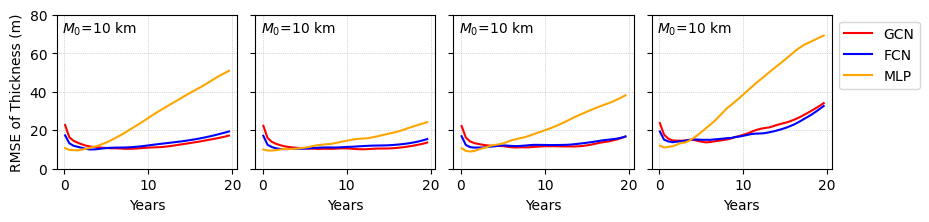

In [213]:
## Channel 3
grid = 10000
print(grid)

vmax = [5000, 5000, 2000, 5000]
vmin = [-5000, -5000, 0, 0]
verr = [200, 200, 80, 350]
cm = ["Spectral", "Spectral", "jet", "jet", "jet", "RdBu"]
channels = ["U velocity", "V velocity", "Thickness (m)", "Velocity (m/y)", ]
["fcn", "mlp", "gcn", "gat", "egcn"]
colors = ["red", "blue", "orange", "red", "maroon", "k"]
meshsize = {526: 20, 1112: 10, 2468: 5}
model_types = ["gcn", "fcn", "mlp"]

c = 2
fig, ax = plt.subplots(1, len(test_gnn_files), figsize = (len(test_gnn_files)*2.5, 2), sharey = True)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

for m, model_type in enumerate(model_types):
    for ci, _ in enumerate(test_gnn_files):
        r = test_gnn_files[ci].split("_r")[1][:3]
        ax[ci].plot(years_real[idxs]-2004, pig_rmse[grid][model_type][ci, :, c], color = colors[m], label=f"{model_type.upper()}")
        ax[ci].grid(ls = ":", lw=0.5)
        ax[ci].set_xlabel("Years")
        if grid == 2000:
            ax[ci].set_title(f"r = {int(r)} m/y", fontsize = 10)
        ylim1, ylim2 = ax[ci].set_ylim(0, verr[c])
        if m == 0:
            ax[ci].annotate(f"$M_{0}$={int(grid/1000)} km", xy=(0.03, 0.97), xycoords='axes fraction', fontsize=10, ha='left', va='top')
    
ax[0].set_ylabel("RMSE of " + channels[c])
plt.legend(bbox_to_anchor=(1,1), loc = "upper left")

# Sensitivity analysis (how PIG responses to different melting rates)

## GNN emulators

In [367]:
in_channels = 10
out_channels = 3

if out_channels == 4:
    scaling = [10000, 10000, 5000, 1]
if out_channels == 3:
    scaling = [10000, 10000, 5000]

_, test_files, _ = generate_list(region = "PIG", folder = "D:\\ISSM\\version3\\", model = "gnn")

vol = {}
vel = {}

for grid in [2000, 5000, 10000]:
    
    # train_dataset = CNN_PIG_Dataset(train_files[:])
    files_m = glob.glob(f"D:\\ISSM\\version3\\PIG_transient_m{str(grid).zfill(5)}_r*.mat") # [f for f in test_files if f.split("_m")[1][:5] == str(grid).zfill(5) ]
    test_set = GNN_PIG_Dataset(files_m[:1])
    test_gnn_files = files_m
    
    vol[grid] = {} #np.zeros((len(time_ranges), len(r_ranges), len(smb_ranges)))   
    vel[grid] = {}
    
    test = sio.loadmat(files_m[0])

    xc = test['S'][0][0][0]
    yc = test['S'][0][0][1]
    # point to calculate distance
    x0 = -1.62 * 1e6
    y0 = -0.37 * 1e6
    elements = test['S'][0][0][2]-1 
    smb0 = test_set[0].ndata['feat'][:, 4].clone()    

    idxs = np.array([60, 120, 180, 239])

    timestep = len(test_set)
    n_area = node_area(xc, yc, elements)
    n_nodes = len(test_set[0].nodes())

    print("M0: ", grid, "; Nodes: ", n_nodes, "; Elements: ", len(elements))
    
    # Grid data
    gridx, gridy, grid_valid, coord = prepare_grid_data(xc, yc)
    
    test_graphs = GNN_PIG_Dataset(test_gnn_files)

    for model_type in ["mlp", "gcn"]:
        
        hidden_channels = 128
        if model_type == "gcn":
            model = GCN(in_channels, out_channels, hidden_channels)  # Graph convolutional network    
        elif model_type == "mlp":
            model = MLP(in_channels, out_channels, hidden_channels)  # Fully connected network
        elif model_type == "gat":
            model = GAT(in_channels, out_channels, hidden_channels)  # Graph convolutional network 
        elif model_type == "egcn":
            model = EGCN(in_channels, out_channels-2, hidden_channels, 5) # Equivariant Graph convolutional network 

        for device_name in ["cuda"]:

            # emulator = f"D:\\ISSM\\model\\torch_dgl_PIG_{model_type}_6384_lr0.001_ch{out_channels}.pth"
            emulator = f"D:\\ISSM\\model\\torch_dgl_PIG_{model_type}_6384_lr0.01_ch{out_channels}.pth"
            device = torch.device(device_name)

            if device_name == "cuda":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.to(device)
            else:
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.module.to(device)

            model.eval()           

            vol[grid][model_type] = np.zeros((len(test_gnn_files), len(idxs)))
            vel[grid][model_type] = np.zeros((len(test_gnn_files), len(idxs)))
            vel[grid]['ISSM'] = np.zeros((len(test_gnn_files), len(idxs)))
            vol[grid]['ISSM'] = np.zeros((len(test_gnn_files), len(idxs)))
            
            for i, _ in tqdm(enumerate(test_gnn_files)):
            
                r = test_gnn_files[i].split("_r")[1][:3]

                test_graph = test_graphs[i*timestep:(i+1)*timestep]
                
                years_real = np.arange(0, timestep)/timestep * 20 + 2004

                test_loader = GraphDataLoader(test_graph, batch_size=1, shuffle=False)  #DataLoader(test_grid, batch_size=1, shuffle=False)               
            
                y_pred = np.zeros((len(idxs), n_nodes, out_channels))
                y_true = np.zeros((len(idxs), n_nodes, out_channels))

                for j, idx in enumerate(idxs):                
                    bg = test_graph[idx]
                    bg = bg.to(device)
                    feats = bg.ndata['feat'][:, 2:]

                    coord_feat = bg.ndata['feat'][:, :2]
                    edge_feat = bg.edata['weight'].float() #.repeat(1, 2)
                    if out_channels == 4:
                        labels = bg.ndata['label'][:, [0,1,4,5]]
                    elif out_channels == 3:
                        labels = bg.ndata['label'][:, [0,1,4]]
                    else:
                        labels = bg.ndata['label'][:, :]    

                    pred = model(bg, feats)

                    y_pred[j] = pred.cpu().detach().numpy() * scaling
                    y_true[j] = labels.cpu().detach().numpy() * scaling      

                    vol_pred0 = griddata(coord, y_pred[j, :, 2], (gridx, gridy), method='linear') * grid_valid
                    vel_pred0 = griddata(coord, (y_pred[j, :, 0]**2+y_pred[j, :, 1]**2)**0.5, (gridx, gridy), method='linear') * grid_valid
                    vol[grid][model_type][i, j] = np.nansum(vol_pred0)*500**2 / 1e9
                    vel[grid][model_type][i, j] = np.nanmean(vel_pred0)
                    
                    if model_type == "gcn":
                        vol_true0 = griddata(coord, y_true[j, :, 2], (gridx, gridy), method='linear') * grid_valid
                        vel_true0 = griddata(coord, (y_true[j, :, 0]**2+y_pred[j, :, 1]**2)**0.5, (gridx, gridy), method='linear') * grid_valid                   
                        vol[grid]['ISSM'][i, j] = np.nansum(vol_true0)*500**2 / 1e9
                        vel[grid]['ISSM'][i, j] = np.nanmean(vel_true0)

        print(model_type, grid)
    
print("COMPLETE!")

100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [00:09<00:00,  9.21s/it]


M0:  2000 ; Nodes:  6384 ; Elements:  12459
Polygon prepared!


100%|█████████████████████████████████████████████████████████████████████████████████| 36/36 [01:05<00:00,  1.83s/it]
36it [02:19,  3.88s/it]


mlp 2000


36it [04:48,  8.01s/it]


...

M0:  10000 ; Nodes:  1833 ; Elements:  3511
Polygon prepared!


100%|█████████████████████████████████████████████████████████████████████████████████| 36/36 [00:25<00:00,  1.40it/s]
36it [00:20,  1.78it/s]


mlp 10000


36it [00:40,  1.13s/it]

gcn 10000
COMPLETE!


## CNN emulators

In [368]:
for grid in [2000, 5000, 10000]:
    
    # train_dataset = CNN_PIG_Dataset(train_files[:])
    test_gnn_files = glob.glob(f"D:\\ISSM\\version3\\PIG_transient_m{str(grid).zfill(5)}_r*.mat")
    test_cnn_files = glob.glob(f"D:\\ISSM\\version3\\PIG_transient_m{str(grid).zfill(5)}_r*.pkl")
    test_set = GNN_PIG_Dataset(test_gnn_files[:1])
    
    test = sio.loadmat(test_gnn_files[0])

    xc = test['S'][0][0][0]
    yc = test['S'][0][0][1]
    # point to calculate distance
    x0 = -1.62 * 1e6
    y0 = -0.37 * 1e6
    elements = test['S'][0][0][2]-1 
    smb0 = test_set[0].ndata['feat'][:, 4].clone()    

    idxs = np.array([60, 120, 180, 239])

    timestep = len(test_set)
    n_area = node_area(xc, yc, elements)
    n_nodes = len(test_set[0].nodes())

    print("M0: ", grid, "; Nodes: ", n_nodes, "; Elements: ", len(elements))
    
    # Grid data
    gridx, gridy, grid_valid, coord = prepare_grid_data(xc, yc)
    
    test_graphs = GNN_PIG_Dataset(test_gnn_files)

    for model_type in ["fcn"]:

        if model_type == "cnn":
            model = CNN(in_channels, out_channels, n_nodes, nrow, ncol, 32)  # convolutional network
        elif model_type == "fcn":
            model = FCN(in_channels, out_channels, 64)

        for device_name in ["cuda"]:

            print(f"Model: {model_type}, Device: {device_name}")

            emulator = f"D:\\ISSM\\model\\torch_dgl_PIG_{model_type}_6384_lr0.001_ch{out_channels}.pth"
            device = torch.device(device_name)

            if device_name == "cuda":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.to(device)
            elif device_name == "cpu":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.module.to(device)

            model.eval()

            vol[grid][model_type] = np.zeros((len(test_gnn_files), len(idxs)))
            vel[grid][model_type] = np.zeros((len(test_gnn_files), len(idxs)))

            for i, _ in enumerate(test_cnn_files):

                r = test_cnn_files[i].split("_r")[1][:3]

                test_grid = CNN_PIG_Dataset(test_cnn_files[i:i+1])
                test_graph = test_graphs[i*timestep:(i+1)*timestep]
                
                sampling = get_sampling_index(test_graph[0].ndata['feat'][:, 0:2], test_grid[0][0][:2])

                years_real = np.arange(0, timestep)/timestep * 20 + 2004

                y_pred = np.zeros((len(idxs), n_nodes, out_channels))
                y_true = np.zeros((len(idxs), n_nodes, out_channels))

                for j, _ in enumerate(idxs):

                    t0 = time.time()
                    data = test_grid[idxs[j]:idxs[j]+1][0]
                    if out_channels == 4:
                        target = test_graph[idxs[j]].ndata['label'][:, [0,1,4,5]] #test_grid[idxs[j]:idxs[j]+1][1]
                    elif out_channels == 3:
                        target = test_graph[idxs[j]].ndata['label'][:, [0,1,4]] #test_grid[idxs[j]:idxs[j]+1][1]

                    data = data[:, 2:]
                    coords = data[:, :2]                

                    pred = model(data)
                    y_pred[j] = pred[0, :out_channels, sampling[:, 0], sampling[:, 1]].t().cpu().detach().numpy() * scaling
                    y_true[j] = target.cpu().detach().numpy() * scaling   

                    vol_pred0 = griddata(coord, y_pred[j, :, 2], (gridx, gridy), method='linear') * grid_valid
                    vel_pred0 = griddata(coord, (y_pred[j, :, 0]**2+y_pred[j, :, 1]**2)**0.5, (gridx, gridy), method='linear') * grid_valid
                    vol[grid][model_type][i, j] = np.nansum(vol_pred0)*500**2 / 1e9
                    vel[grid][model_type][i, j] = np.nanmean(vel_pred0)

        print(model_type, grid)
    
print("COMPLETE!")

100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.89s/it]


M0:  2000 ; Nodes:  6384 ; Elements:  12459
Polygon prepared!


100%|█████████████████████████████████████████████████████████████████████████████████| 36/36 [00:47<00:00,  1.31s/it]


Model: fcn, Device: cuda


100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [00:05<00:00,  5.06s/it]


...

M0:  10000 ; Nodes:  1833 ; Elements:  3511
Polygon prepared!


100%|█████████████████████████████████████████████████████████████████████████████████| 36/36 [00:27<00:00,  1.33it/s]


Model: fcn, Device: cuda


100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.48s/it]


fcn 10000
COMPLETE!


ISSM -3.2335636788990954
gcn -2.3654005007442933
fcn -2.5070119290001855
mlp -1.7522003133739332
ISSM -3.1630245617016683
gcn -2.406256981926944
fcn -2.5271733243785235
mlp -1.7683937205581088
ISSM -3.1201484917870275
gcn -2.2626560873654
fcn -2.5115183318200636
mlp -1.757399795381133


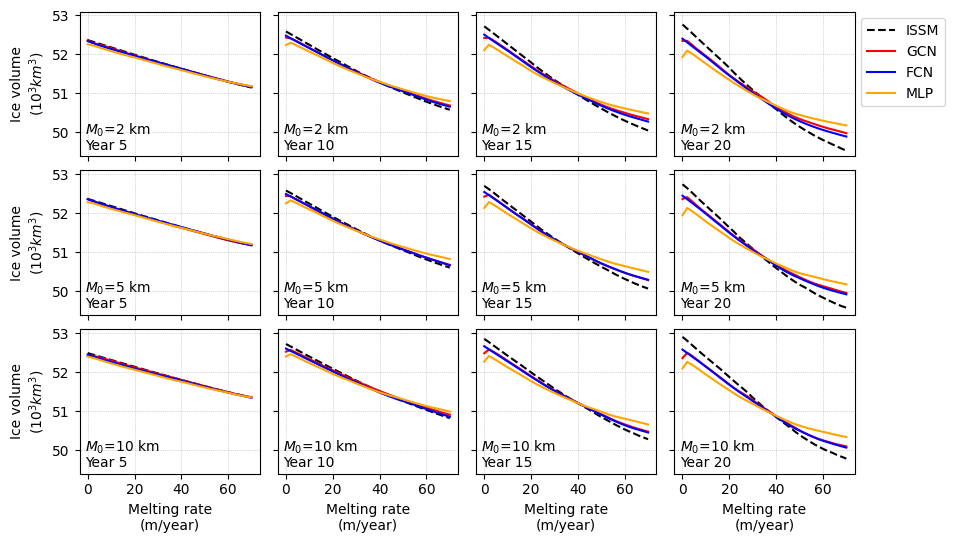

In [371]:
colors = ["k", "red", "blue", "orange", "red", "maroon"]
model_types = ['ISSM', 'gcn', 'fcn', 'mlp']

grids = [2000, 5000, 10000]
fig, ax = plt.subplots(len(grids), len(idxs), figsize = (len(idxs)*2.5, len(grids)*2), dpi = 100, sharey = True, sharex = True)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

for g, grid in enumerate(grids):    

    # fig, ax = plt.subplots(1,/ len(inds), figsize = (len(inds)*2.5, 2), sharey = True)    

    for i, ind in enumerate(idxs):
        for m, model in enumerate(model_types):
            if model == "ISSM":
                ls = "--"; lw = 1.5
            else:
                ls = "-"; lw = 1.5

            vol_mean = vol[grid][model][:, i]/1000

            ax[g, i].plot(vol_mean, label = model.upper(), color = colors[m], ls=ls, lw=lw)
            if i == 3:
                print(model, vol_mean[-1] - vol_mean[0])
            rates = np.array([0, 10, 20, 30])
        ax[g, i].set_xticks(rates, rates*2)
        ax[g, i].grid(ls = ":", lw = 0.5)
        ax[g, i].annotate(f"$M_{0}$={int(grid/1000)} km", xy=(0.03, 0.12), xycoords='axes fraction', fontsize=10, ha='left', va='bottom')
        if ind == 240:
            ax[g, i].annotate(f"20-year mean", xy=(0.03, 0.12), xycoords='axes fraction', fontsize=10, ha='left', va='top', weight='bold')
        else:
            ax[g, i].annotate(f"Year {round(ind/12)}", xy=(0.03, 0.12), xycoords='axes fraction', fontsize=10, ha='left', va='top')
    
        ax[-1, i].set_xlabel("Melting rate\n(m/year)")
        ax[g, i].set_ylim(49.4, 53.1)
    ax[g, 0].set_ylabel("Ice volume\n($10^3 km^3$)")
    
    if g == 0:
        ax[g, -1].legend(bbox_to_anchor=(1,1), loc = "upper left")

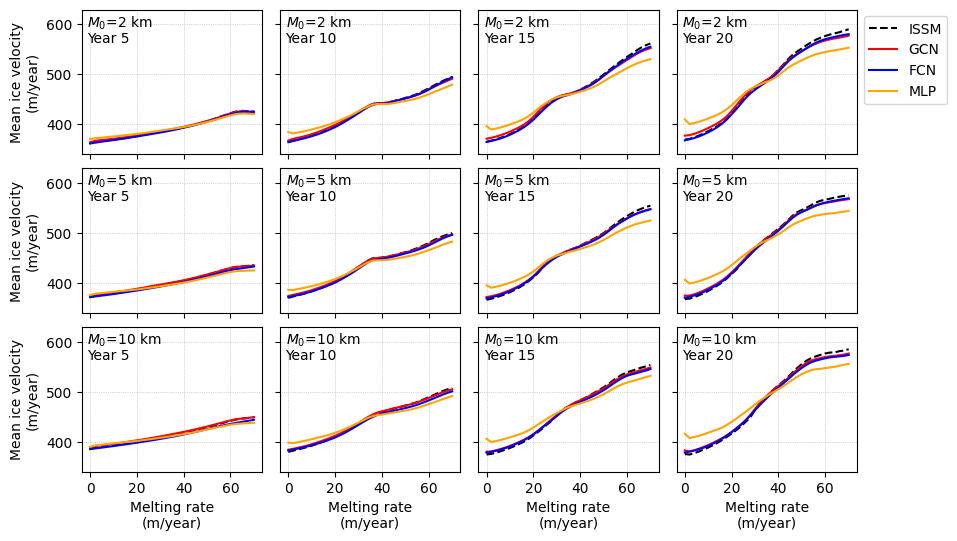

In [291]:
colors = ["k", "red", "blue", "orange", "red", "maroon"]
model_types = ['ISSM', 'gcn', 'fcn', 'mlp']
grids = [2000, 5000, 10000]
fig, ax = plt.subplots(len(grids), len(idxs), figsize = (len(idxs)*2.5, len(grids)*2), dpi = 100, sharey = True, sharex = True)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

for g, grid in enumerate(grids):    

    for i, ind in enumerate(idxs):
        for m, model in enumerate(model_types):
            if model == "ISSM":
                ls = "--"; lw = 1.5
            else:
                ls = "-"; lw = 1.5

            vel_mean = vel[grid][model][:, i]
            
            ax[g, i].plot(vel_mean, label = model.upper(), color = colors[m], ls=ls, lw=lw)

            rates = np.array([0, 10, 20, 30])
        ax[g, i].set_xticks(rates, rates*2)
        ax[g, i].grid(ls = ":", lw = 0.5)
        ax[g, i].annotate(f"$M_{0}$={int(grid/1000)} km", xy=(0.03, 0.85), xycoords='axes fraction', fontsize=10, ha='left', va='bottom')
        if ind == 240:
            ax[g, i].annotate(f"20-year mean", xy=(0.03, 0.85), xycoords='axes fraction', fontsize=10, ha='left', va='top', weight='bold')
        else:
            ax[g, i].annotate(f"Year {round(ind/12)}", xy=(0.03, 0.85), xycoords='axes fraction', fontsize=10, ha='left', va='top')
    
        ax[-1, i].set_xlabel("Melting rate\n(m/year)")
        ax[g, i].set_ylim(340, 630)
        
    ax[g, 0].set_ylabel("Mean ice velocity\n(m/year)")
    if g == 0:
        ax[g, -1].legend(bbox_to_anchor=(1,1), loc = "upper left")

In [17]:
test = [f for f in test_files if f.split("_m")[1][:5] == str(grid).zfill(5) ]

In [19]:
files_m = [f for f in test_files if f.split("_m")[1][:5] == str(grid).zfill(5) ]
test_set = GNN_PIG_Dataset(files_m[:1])

100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.50s/it]


In [26]:
np.arange(0.8, 1.2, 0.01)

array([0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9 ,
       0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.  , 1.01,
       1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1 , 1.11, 1.12,
       1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19])

In [141]:
test_set = GNN_PIG_Dataset(files_m[:1])

100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.34s/it]


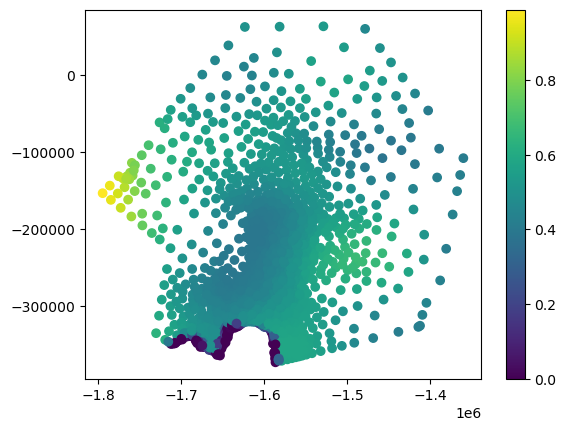

In [142]:
plt.scatter(xc, yc, c = test_set[1].ndata['feat'][:, 4]*20)
plt.colorbar()

In [40]:
len(test_set)

240

In [173]:
in_channels = 10
out_channels = 4

if out_channels == 4:
    scaling = [10000, 10000, 5000, 5000, 10000]

_, _, test_files = generate_list(region = "PIG", folder = "D:\\ISSM\\version3\\", model = "gnn")

test

vol = {}

for grid in [10000]:     
    
    # train_dataset = CNN_PIG_Dataset(train_files[:])
    files_m = [f for f in test_files if f.split("_m")[1][:5] == str(grid).zfill(5) ]
    test_set = GNN_PIG_Dataset(files_m[:1])
    
    # Experimental ranges
    r_ranges = np.arange(0, 71, 5)
    smb_ranges = np.arange(0.5, 1.5, 0.05)
    time_ranges = np.arange(0, 1, 0.05)
    vol[grid] = np.zeros((len(time_ranges), len(r_ranges), len(smb_ranges)))
    
    files = glob.glob(f'D:\\ISSM\\version3\\PIG_transient_m{str(grid).zfill(5)}_r*.mat')[:]
    
    test = sio.loadmat(files[0])

    xc = test['S'][0][0][0]
    yc = test['S'][0][0][1]
    elements = test['S'][0][0][2]-1 
    smb0 = test_set[0].ndata['feat'][:, 4].clone()
    
    n_area = node_area(xc, yc, elements)[0]

    n_nodes = len(test_set[0].nodes())

    for model_type in ["gcn"]:
        
        hidden_channels = 128
        if model_type == "gcn":
            model = GCN(in_channels, out_channels, hidden_channels)  # Graph convolutional network    
        elif model_type == "mlp":
            model = MLP(in_channels, out_channels, hidden_channels)  # Fully connected network
        elif model_type == "gat":
            model = GAT(in_channels, out_channels, hidden_channels)  # Graph convolutional network 
        elif model_type == "egcn":
            model = EGCN(in_channels, out_channels, hidden_channels, 1) # Equivariant Graph convolutional network 

        for device_name in ["cuda"]:

            emulator = f"D:\\ISSM\\model\\torch_dgl_PIG_{model_type}_6384_lr0.001_ch{out_channels}.pth"
            device = torch.device(device_name)

            if device_name == "cuda":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.to(device)
            elif device_name == "cpu":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.module.to(device)

            # model.load_state_dict(torch.load(emulator))

            # model.to(device)
            model.eval()

            print("Number of nodes: ", n_nodes, "; Time: ", len(time_ranges),  "; Melting rates: ", len(r_ranges), "; SMB: ", len(smb_ranges))
            for n, r in tqdm(enumerate(r_ranges)):
                
                for m, smb in enumerate(smb_ranges):                  

                    for t, t0 in enumerate(time_ranges):
                        
                        bg = test_set[0]
                        
                        part_set.ndata['feat'][:, 2] = r * 0.01
                        part_set.ndata['feat'][:, 4] = smb * smb0
                        part_set.ndata['feat'][:, 3] = t0
                        
                        bg = part_set

                        t0 = time.time()

                        bg = bg.to(device)
                        feats = bg.ndata['feat'][:, 2:]
                        coord_feat = bg.ndata['feat'][:, :2]
                        edge_feat = bg.edata['slope'].float() #.repeat(1, 2)
                        if out_channels == 4:
                            labels = bg.ndata['label'][:, [0, 1, 4, 5]]
                        elif out_channels == 3:
                            labels = bg.ndata['label'][:, [0,1,3]]               

                        with torch.no_grad():
                            pred = model(bg, feats)

                            if out_channels == 4:
                                y_true = add_vel(labels.cpu()) * scaling
                                y_pred = add_vel(pred.cpu()) * scaling
                                
                            n_vol = n_area * y_pred[:, 2]

                            vol[grid][t, n, m] = np.sum(n_vol) / 1e9 #area_mean(xc, yc, elements, y_pred[:, 2])[0] # np.sum(H[]*area) / np.sum(area) #np.mean(y_true[:, :, c])  
                            # vel[grid][t, i] = area_mean(xc, yc, elements, y_pred[:, 3])[1] #np.mean(y_pred[:, :, c])
                
        print(model_type, grid)
        
    # with open(f'../results/sensitivity_{grid}.pkl', 'wb') as f:
    #     pickle.dump([sens_vol[grid], sens_vel[grid]], f)

100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.24s/it]


Number of nodes:  1833 ; Time:  20 ; Melting rates:  15 ; SMB:  20


15it [01:38,  6.55s/it]

gcn 10000


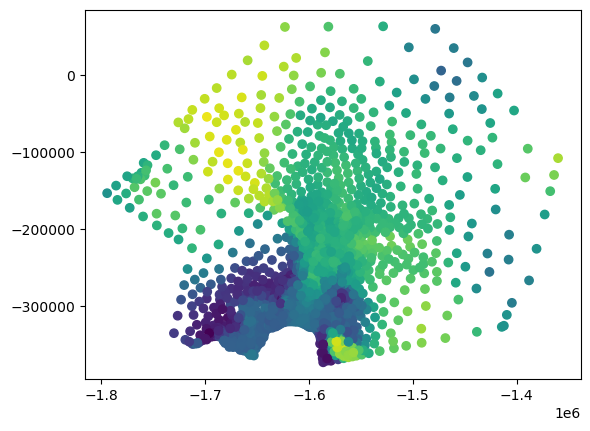

In [183]:
plt.scatter(xc, yc, c = y_pred[:, 2])

Text(0, 0.5, 'Surface mass balance (* times)')

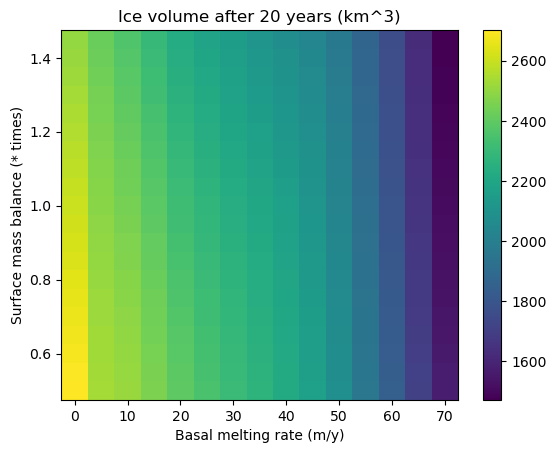

In [181]:
r0, smb0 = np.meshgrid(r_ranges, smb_ranges)
plt.pcolormesh(r0, smb0, vol[10000][-1].transpose())
plt.colorbar()
plt.title("Ice volume after 20 years (km^3)")
plt.xlabel("Basal melting rate (m/y)")
plt.ylabel("Surface mass balance (* times)")